# EfficientNet Train and Testing

Referenced from TensorFlow EfficientNet training
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/load_data/video.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />TensorFlow Notebook</a>
  </td>
  

--- 1: PULSE CHECK ---
Extraction Time (1 Video, 10 Frames): 0.4818 seconds
Whole Package Average Pixel: 79.34/255
  Frame 1 Avg: 75.87
  Frame 2 Avg: 75.76
  Frame 3 Avg: 78.20
  Frame 4 Avg: 80.67
  Frame 5 Avg: 81.26
  Frame 6 Avg: 81.09
  Frame 7 Avg: 80.33
  Frame 8 Avg: 80.16
  Frame 9 Avg: 79.91
  Frame 10 Avg: 80.13


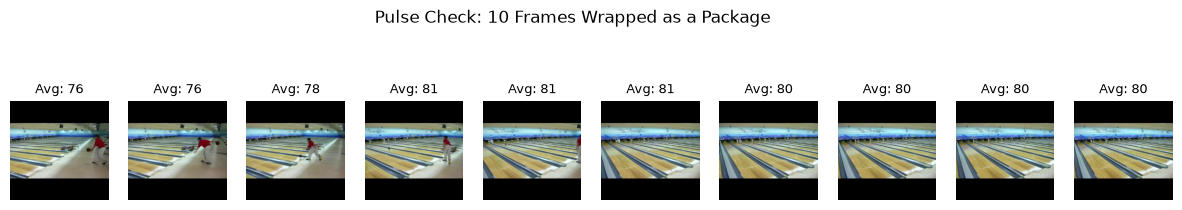


--- 2: MODEL TRAINING ---
Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 153ms/step - accuracy: 0.5000 - loss: 0.7079
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5000 - loss: 0.6674
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5000 - loss: 0.6973
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5000 - loss: 0.6957
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5000 - loss: 0.6914
Total Training Time (5 epochs): 22.44 seconds

--- 3: PREDICTION & VISUALIZATION ---
Test Video 1: v_Bowling_g05_c07.avi
  Prediction Time: 23.7634s
  Predicted: classA (53.2%) | Actual: classA
  Status: CORRECT



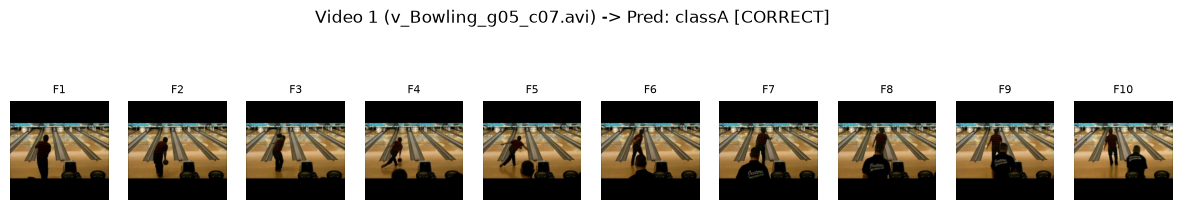

Test Video 2: v_Fencing_g05_c02.avi
  Prediction Time: 0.2609s
  Predicted: classA (53.2%) | Actual: classB
  Status: INCORRECT



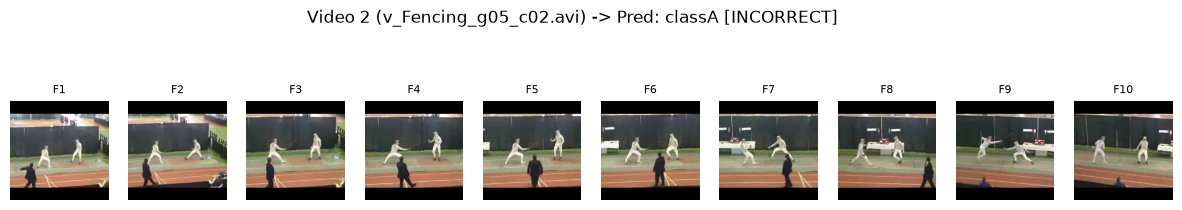

FINAL ACCURACY: 50% (1/2 correct)


In [ ]:
import os
import time
import random
import pathlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


# Define paths
train_dir = pathlib.Path('/Downloads/tensorflow video/training')
test_videos = [
    {
        'path': '/Downloads/tensorflow video/test/v_Bowling_g05_c07.avi', 
        'actual': 'classA'
    },
    {
        'path': '/Downloads/tensorflow video/test/v_Fencing_g05_c02.avi', 
        'actual': 'classB'
    }
]

# Core Functions:

def format_frames(frame, output_size):
    """Pad and resize an image from a video to [0.0, 1.0]."""
    frame = tf.image.convert_image_dtype(frame, tf.float32)
    frame = tf.image.resize_with_pad(frame, *output_size)
    return frame

def frames_from_video_file(video_path, n_frames=10, output_size=(224, 224), frame_step=None):
    src = cv2.VideoCapture(str(video_path))
    video_length = int(src.get(cv2.CAP_PROP_FRAME_COUNT))

    if video_length <= 0:
        src.release()
        return np.zeros((n_frames, *output_size, 3), dtype=np.float32)

    # Pick n_frames evenly spaced
    frame_indices = np.linspace(0, video_length - 1, n_frames, dtype=int)

    result = []
    for idx in frame_indices:
        src.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = src.read()
        if ret:
            result.append(format_frames(frame, output_size))
        else:
            result.append(result[-1] if result else np.zeros((*output_size, 3), dtype=np.float32))

    src.release()
    # Convert BGR to RGB
    result = np.array(result)[..., [2, 1, 0]]
    return result

class FrameGenerator:
    def __init__(self, path, n_frames, training=False):
        self.path = path
        self.n_frames = n_frames
        self.training = training
        self.class_names = sorted(set(p.name for p in self.path.iterdir() if p.is_dir()))
        self.class_ids_for_name = dict((name, idx) for idx, name in enumerate(self.class_names))

    def get_files_and_class_names(self):
        video_paths = list(self.path.glob('*/*.avi'))
        classes = [p.parent.name for p in video_paths] 
        return video_paths, classes

    def __call__(self):
        video_paths, classes = self.get_files_and_class_names()
        pairs = list(zip(video_paths, classes))
        if self.training:
            random.shuffle(pairs)
        for path, name in pairs:
            video_frames = frames_from_video_file(path, self.n_frames) 
            label = self.class_ids_for_name[name]
            yield video_frames, label


# (1) Pulse Check (make sure we get an output)
print("--- 1: PULSE CHECK ---")
fg = FrameGenerator(train_dir, n_frames=10, training=True)
class_names = fg.class_names

# Get one video for pulse check
sample_video = list(train_dir.glob('*/*.avi'))[0]

start_extract = time.perf_counter()
pulse_frames = frames_from_video_file(sample_video, n_frames=10)
extract_time = time.perf_counter() - start_extract

# Convert [0.0, 1.0] pixels to standard [0, 255] space
pulse_frames_255 = pulse_frames * 255.0
frame_averages = [np.mean(frame) for frame in pulse_frames_255]
video_average = np.mean(pulse_frames_255)

print(f"Extraction Time (1 Video, 10 Frames): {extract_time:.4f} seconds")
print(f"Whole Package Average Pixel: {video_average:.2f}/255")
for i, avg in enumerate(frame_averages):
    print(f"  Frame {i+1} Avg: {avg:.2f}")

# Show the frames
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle(f"Pulse Check: 10 Frames Wrapped as a Package", y=1.2)
for i, ax in enumerate(axes):
    ax.imshow(pulse_frames[i]) 
    ax.set_title(f"Avg: {frame_averages[i]:.0f}", fontsize=9)
    ax.axis('off')
plt.show()

# (2) Training Pipeline 

print("\n--- 2: MODEL TRAINING ---")
output_signature = (
    tf.TensorSpec(shape=(None, None, None, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(), dtype=tf.int16)
)

train_ds = tf.data.Dataset.from_generator(
    FrameGenerator(train_dir, n_frames=10, training=True),
    output_signature=output_signature
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(buffer_size=4).batch(2).prefetch(buffer_size=AUTOTUNE)

net = tf.keras.applications.EfficientNetB0(include_top=False)
net.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.TimeDistributed(net),
    tf.keras.layers.Dense(len(class_names)),
    tf.keras.layers.GlobalAveragePooling3D()
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

start_train = time.perf_counter()
model.fit(train_ds, epochs=5)
train_time = time.perf_counter() - start_train
print(f"Total Training Time (5 epochs): {train_time:.2f} seconds")

# (3) Testing

print("\n--- 3: PREDICTION & VISUALIZATION ---")
correct_predictions = 0

for idx, test_vid in enumerate(test_videos):
    start_predict = time.perf_counter()
    
    # Get the 10-frame package from test videos
    test_frames = frames_from_video_file(test_vid['path'], n_frames=10)
    input_package = np.expand_dims(test_frames, axis=0)
    
    # Predict
    logits = model.predict(input_package, verbose=0)
    probabilities = tf.nn.softmax(logits[0]).numpy()
    pred_idx = np.argmax(probabilities)
    predicted_label = class_names[pred_idx]
    predict_time = time.perf_counter() - start_predict
    
    is_correct = (predicted_label.lower() == test_vid['actual'].lower())
    if is_correct:
        correct_predictions += 1
        
    print(f"Test Video {idx+1}: {os.path.basename(test_vid['path'])}")
    print(f"  Prediction Time: {predict_time:.4f}s")
    print(f"  Predicted: {predicted_label} ({probabilities[pred_idx]*100:.1f}%) | Actual: {test_vid['actual']}")
    print(f"  Status: {'CORRECT' if is_correct else 'INCORRECT'}\n")

    # Display 10 frames of each vid
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    status_text = "CORRECT" if is_correct else "INCORRECT"
    fig.suptitle(f"Video {idx+1} ({os.path.basename(test_vid['path'])}) -> Pred: {predicted_label} [{status_text}]", y=1.2)
    for f_idx, ax in enumerate(axes):
        ax.imshow(np.clip(test_frames[f_idx], 0.0, 1.0))
        ax.set_title(f"F{f_idx+1}", fontsize=8)
        ax.axis('off')
    plt.show()

accuracy = (correct_predictions / len(test_videos)) * 100
print(f"FINAL ACCURACY: {accuracy:.0f}% ({correct_predictions}/{len(test_videos)} correct)")